# Mid-Level API — Walkthrough on the Asia Bayesian Network

Applied counterpart to `mid_level_api_overview.ipynb`. We exercise the four inference engines on the **Asia** BN — 8 binary symptoms / diseases — using the canonical bnlearn DAG.

Outline:
1. Load the dataset and define the DAG.
2. Helper to build a fresh `ProbabilisticModel`.
3. Four training examples: `DeterministicInference`, `AncestralInference`, `VariationalInference`, and Pyro's `Trace_ELBO` directly on the same model + guides.
4. Reporting: loss curves and a 4×8 accuracy table.
5. Backward queries via `pyro.infer.Importance`.

## Setup

In [1]:
import warnings
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import pyro
import pyro.distributions as dist
import pyro.poutine as poutine
from pyro.infer import Importance, Trace_ELBO

from torch_concepts.nn.modules.pgm import (
    ConceptVariable, ExogenousVariable,
    ParametricCPD, ProbabilisticModel,
    DeterministicInference, AncestralInference, VariationalInference,
)
from torch_concepts.data.datamodules.bnlearn import BnLearnDataModule

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED); pyro.set_rng_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

/home/francesco/projects/pytorch_concepts/torch_concepts/nn/modules/high/base/model.py:40: FutureWarning: The 'torch_concepts.nn.mid' module contains experimental APIs that are unstable and subject to change without notice. If you are using these classes intentionally, be aware that breaking changes may occur in future releases. Consider using the high-level API (torch_concepts.nn.high) for stable interfaces.
  from ...mid.constructors.concept_graph import ConceptGraph


device: cuda


## 1. Data and Asia DAG

`BnLearnDataModule` autoencodes the raw 8-bit concept labels into a 32-dim continuous embedding `x`. The labels themselves remain binary.

In [2]:
dm = BnLearnDataModule(
    seed=SEED, name='asia',
    autoencoder_kwargs={'latent_dim': 32}, batch_size=512,
)
dm.setup('fit'); dm.setup('test')

concept_names = list(dm.dataset.concept_names)
x_dim = dm.dataset.input_data.shape[-1]

ASIA_PARENTS = {
    'asia':   [],
    'smoke':  [],
    'tub':    ['asia'],
    'lung':   ['smoke'],
    'bronc':  ['smoke'],
    'either': ['tub', 'lung'],
    'xray':   ['either'],
    'dysp':   ['either', 'bronc'],
}
ROOTS_OF_ASIA = ('asia', 'smoke')   # x feeds these roots only

assert set(ASIA_PARENTS) == set(concept_names)
print('concepts:', concept_names)
print('x_dim   :', x_dim)

INFO:torch_concepts.data.datasets.bnlearn:Loading dataset from /home/francesco/projects/pytorch_concepts/examples/utilization/data/asia


INFO:torch_concepts.data.base.datamodule:Input shape: (32,)


INFO:torch_concepts.data.base.datamodule:Using raw input data without backbone preprocessing.


INFO:torch_concepts.data.base.datamodule:Input shape: (32,)


INFO:torch_concepts.data.base.datamodule:Using raw input data without backbone preprocessing.


concepts: ['asia', 'tub', 'smoke', 'lung', 'bronc', 'either', 'xray', 'dysp']
x_dim   : 32


## 2. Build a fresh PGM

Same architecture for every example: a 2-layer MLP per concept, hidden=64. Roots `asia` and `smoke` read `x`; the other concepts read only their concept parents.

In [3]:
def build_pgm() -> ProbabilisticModel:
    variables = [ExogenousVariable('x', size=x_dim)]
    for c in concept_names:
        variables.append(ConceptVariable(c, distribution=dist.Bernoulli))

    factors = [ParametricCPD('x', nn.Identity())]
    for c in concept_names:
        parents = (['x'] if c in ROOTS_OF_ASIA else []) + ASIA_PARENTS[c]
        in_dim = sum(x_dim if p == 'x' else 1 for p in parents)
        factors.append(ParametricCPD(
            c,
            nn.Sequential(nn.Linear(in_dim, 64), nn.ReLU(), nn.Linear(64, 1)),
            parents=parents,
        ))
    return ProbabilisticModel(variables, factors)

pgm0 = build_pgm()
print('topo order :', [v.name for v in pgm0.sorted_variables])
print('# params   :', sum(p.numel() for p in pgm0.parameters()))

topo order : ['x', 'asia', 'smoke', 'tub', 'lung', 'bronc', 'either', 'xray', 'dysp']
# params   : 5640


## 3. Helpers — batches and evaluation

In [4]:
EPOCHS, LR = 30, 1e-3

def batch_to_data(batch, drop=()):
    x = batch['inputs']['x'].to(DEVICE)
    c = batch['concepts']['c'].to(DEVICE).float()
    return {'x': x, **{n: c[:, i] for i, n in enumerate(concept_names) if n not in drop}}

def all_test():
    xs, cs = [], []
    for b in dm.test_dataloader():
        xs.append(b['inputs']['x']); cs.append(b['concepts']['c'])
    return torch.cat(xs).to(DEVICE), torch.cat(cs).to(DEVICE).float()

x_test, c_test = all_test()
print('test set:', x_test.shape, c_test.shape)

test set: torch.Size([2000, 32]) torch.Size([2000, 8])


## 4. Example 1 — `DeterministicInference` (fully supervised)

All 8 concept labels are passed in `data`. `p_int=1.0` teacher-forces every parent in the topological propagation. Loss = sum of per-concept Bernoulli NLLs computed from `out.model_params[name]['probs']`.

In [5]:
torch.manual_seed(SEED); pyro.set_rng_seed(SEED)
pgm_det = build_pgm().to(DEVICE)
engine_det = DeterministicInference(pgm_det, p_int=1.0)
optim = torch.optim.Adam(pgm_det.parameters(), lr=LR)

loss_det = []
for epoch in range(EPOCHS):
    for batch in dm.train_dataloader():
        data = batch_to_data(batch)
        out = engine_det(query=concept_names, evidence=['x'], data=data)
        nll = sum(
            -dist.Bernoulli(probs=out.model_params[c]['probs']).log_prob(data[c]).mean()
            for c in concept_names
        )
        optim.zero_grad(); nll.backward(); optim.step()
        loss_det.append(float(nll))
print(f'final det NLL: {loss_det[-1]:.3f}')

final det NLL: 1.505


## 5. Example 2 — `AncestralInference` (ST-relaxed sampling)

Single sample per variable; non-evidence parents are passed downstream as ST-relaxed Bernoulli draws (still differentiable). `p_int=0.5` mixes label teacher-forcing (50%) with sampled parents (50%).

In [6]:
torch.manual_seed(SEED); pyro.set_rng_seed(SEED)
pgm_anc = build_pgm().to(DEVICE)
engine_anc = AncestralInference(
    pgm_anc, p_int=0.5,
    initial_temperature=1.0, annealing='linear', annealing_rate=1e-3,
)
optim = torch.optim.Adam(pgm_anc.parameters(), lr=LR)

loss_anc = []
for epoch in range(EPOCHS):
    for batch in dm.train_dataloader():
        data = batch_to_data(batch)
        out = engine_anc(query=concept_names, evidence=['x'], data=data)
        nll = sum(
            -dist.Bernoulli(probs=out.model_params[c]['probs']).log_prob(data[c]).mean()
            for c in concept_names
        )
        optim.zero_grad(); nll.backward(); optim.step()
        loss_anc.append(float(nll))
print(f'final anc NLL: {loss_anc[-1]:.3f}')

final anc NLL: 1.953


## 6. Example 3 — `VariationalInference` (two latent concepts)

Treat `lung` and `either` as hidden; the engine eagerly builds a Straight-Through Bernoulli guide for each, conditioned on `x`. The loss is data-fit on the 6 observed concepts plus the MC KL `log q(z|x) − log p(z|pa)` for the latents.

In [7]:
LATENTS = ['lung', 'either']
OBSERVED = [c for c in concept_names if c not in LATENTS]

torch.manual_seed(SEED); pyro.set_rng_seed(SEED)
pgm_vi = build_pgm().to(DEVICE)
engine_vi = VariationalInference(
    pgm_vi, latents=LATENTS,
    initial_temperature=1.0, annealing='linear', annealing_rate=1e-3,
).to(DEVICE)
optim = torch.optim.Adam(
    list(pgm_vi.parameters()) + list(engine_vi.parameters()), lr=LR,
)

loss_vi = []
for epoch in range(EPOCHS):
    for batch in dm.train_dataloader():
        data = batch_to_data(batch, drop=LATENTS)
        out = engine_vi(
            query=concept_names,
            evidence=['x'] + OBSERVED,
            data=data,
        )
        # Data fit on observed concepts.
        data_fit = sum(
            dist.Bernoulli(probs=out.model_params[c]['probs']).log_prob(data[c]).mean()
            for c in OBSERVED
        )
        # MC KL for latents using ST-relaxed samples from q.
        kl = 0.0
        for z in LATENTS:
            q_kw = out.guide_params[z]
            p_probs = out.model_params[z]['probs']
            q = dist.RelaxedBernoulliStraightThrough(**q_kw)
            zs = q.rsample()
            p = dist.Bernoulli(probs=p_probs)
            kl = kl + (q.log_prob(zs) - p.log_prob(zs)).mean()
        loss = -(data_fit - kl)
        optim.zero_grad(); loss.backward(); optim.step()
        loss_vi.append(float(loss))
print(f'final vi loss: {loss_vi[-1]:.3f}')

final vi loss: 2.912


## 7. Example 4 — Pyro's `Trace_ELBO` directly on `(pgm, guide)`

Same model and guide architecture as §6, but the loss is computed by Pyro's stock `Trace_ELBO` rather than by the engine's `_run`. The PGM is wrapped in `pyro.plate` so per-sample log-probs sit on the plate dimension.

In [8]:
torch.manual_seed(SEED); pyro.set_rng_seed(SEED)
pgm_te = build_pgm().to(DEVICE)
engine_te = VariationalInference(
    pgm_te, latents=LATENTS,
    initial_temperature=1.0, annealing='linear', annealing_rate=1e-3,
).to(DEVICE)
optim = torch.optim.Adam(
    list(pgm_te.parameters()) + list(engine_te.parameters()), lr=LR,
)
elbo = Trace_ELBO()

def model_fn(data):
    with pyro.plate('data', data['x'].shape[0]):
        return pgm_te(data)

def guide_fn(data):
    with pyro.plate('data', data['x'].shape[0]):
        return engine_te.guide(data, engine_te.temperature)

loss_te = []
for epoch in range(EPOCHS):
    for batch in dm.train_dataloader():
        data = batch_to_data(batch, drop=LATENTS)
        loss = elbo.differentiable_loss(model_fn, guide_fn, data)
        optim.zero_grad(); loss.backward(); optim.step()
        loss_te.append(float(loss))
print(f'final Trace_ELBO loss: {loss_te[-1]:.3f}')

final Trace_ELBO loss: 1490.486


## 8. Reporting

### Loss curves

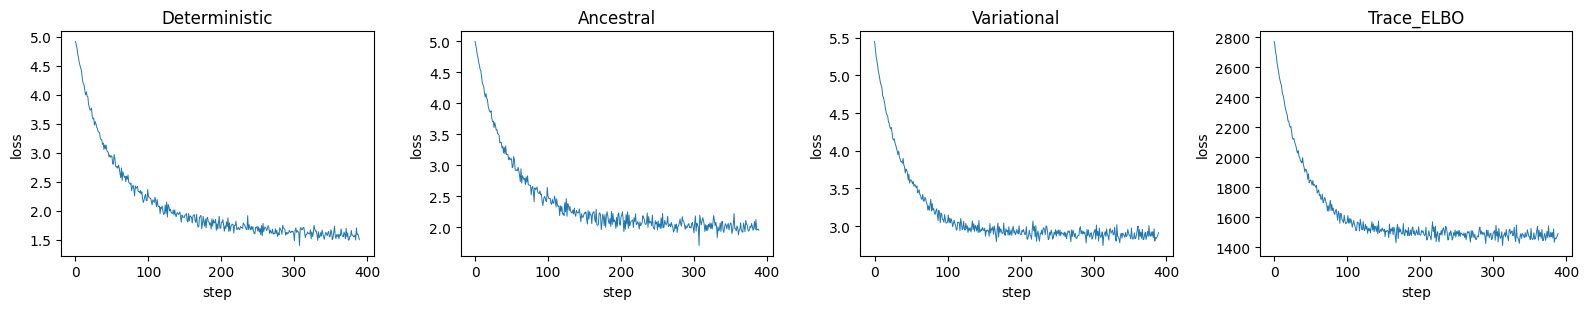

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))
for ax, (label, losses) in zip(axes, [
    ('Deterministic', loss_det),
    ('Ancestral',     loss_anc),
    ('Variational',   loss_vi),
    ('Trace_ELBO',    loss_te),
]):
    ax.plot(losses, lw=0.7)
    ax.set_title(label); ax.set_xlabel('step'); ax.set_ylabel('loss')
fig.tight_layout(); plt.show()

### Per-concept accuracy table

All four trained models are evaluated identically with `DeterministicInference(pgm, p_int=0.0)` on the test set: only `x` is observed, the engine propagates predicted probabilities, and we threshold at 0.5.

In [10]:
@torch.no_grad()
def concept_accuracy(pgm):
    pgm.eval()
    eng = DeterministicInference(pgm, p_int=0.0)
    out = eng(query=concept_names, evidence=['x'], data={'x': x_test})
    accs = {}
    for i, c in enumerate(concept_names):
        p = out.model_params[c]['probs']
        pred = (p > 0.5).float()
        accs[c] = float((pred == c_test[:, i]).float().mean())
    return accs

import pandas as pd
rows = {
    'Deterministic': concept_accuracy(pgm_det),
    'Ancestral':     concept_accuracy(pgm_anc),
    'Variational':   concept_accuracy(pgm_vi),
    'Trace_ELBO':    concept_accuracy(pgm_te),
}
df = pd.DataFrame(rows).T[concept_names]
df['mean'] = df.mean(axis=1)
df.round(3)

,asia,tub,smoke,lung,bronc,either,xray,dysp,mean
Deterministic,0.989,0.993,1.0,0.943,0.653,0.936,0.893,0.565,0.871
Ancestral,0.989,0.993,1.0,0.943,0.653,0.936,0.893,0.565,0.871
Variational,0.989,0.993,1.0,0.058,0.653,0.936,0.893,0.614,0.767
Trace_ELBO,0.989,0.993,1.0,0.058,0.653,0.936,0.893,0.614,0.767


## 9. Backward queries with `pyro.infer.Importance`

Take the §6 trained model and answer $p(\mathbf{q} \mid \mathbf{e}, x)$ by importance-sampling against `poutine.condition(pgm, data=evidence)`. We keep the model on CPU and use a small slice of the test set for clarity.

In [11]:
@torch.no_grad()
def importance_posterior(pgm, evidence, query_vars, num_samples=300):
    conditioned = poutine.condition(pgm, data=evidence)
    importance = Importance(conditioned, num_samples=num_samples)
    posterior = importance.run(evidence)  # evidence is the data arg to pgm.forward
    # Aggregate: weighted mean of each query variable's sampled value.
    log_weights = torch.tensor([t.log_prob_sum() for t in posterior.exec_traces])
    weights = torch.softmax(log_weights, dim=0)
    out = {}
    for q in query_vars:
        vals = torch.stack([t.nodes[q]['value'].detach() for t in posterior.exec_traces])
        # weighted mean over the leading sample axis.
        w = weights.view(-1, *([1] * (vals.ndim - 1)))
        out[q] = (w * vals).sum(dim=0)
    return out

pgm_vi.eval(); pgm_vi.cpu()
x_slice = x_test[:16].cpu()
evidence = {
    'x':    x_slice,
    'xray': torch.ones(x_slice.shape[0]),
    'dysp': torch.ones(x_slice.shape[0]),
}
post = importance_posterior(pgm_vi, evidence, query_vars=['lung', 'either', 'tub'])
for q, v in post.items():
    print(f'{q:8s} posterior mean: {v.mean().item():.3f}')

lung     posterior mean: 0.476
either   posterior mean: 0.443
tub      posterior mean: 1.000


## Summary

We exercised every part of the mid-level API on the Asia BN:

- **Variables / factors / model** — eight `ConceptVariable` Bernoullis plus an `ExogenousVariable` embedding, wired by the canonical Asia DAG.
- **Engines** — `DeterministicInference` (parameter propagation), `AncestralInference` (single ST-relaxed sample, with parent-mixing via `p_int`), `VariationalInference` (eager ST-Bernoulli guides per latent).
- **Pyro interop** — the same `pgm` and `engine.guide` plug straight into `Trace_ELBO`.
- **Backward queries** — `pyro.infer.Importance` on `poutine.condition(pgm, data=evidence)` answers arbitrary marginals.